In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

import numpy as np

import matplotlib.pyplot as plt

In [2]:
def createSomeData(nPerClust):

    A = [1,1]
    B = [5,1]
    C = [4,4]

    a = [ A[0]+np.random.randn(nPerClust), A[1]+np.random.randn(nPerClust) ]
    b = [ B[0]+np.random.randn(nPerClust), B[1]+np.random.randn(nPerClust) ]
    c = [ C[0]+np.random.randn(nPerClust), C[1]+np.random.randn(nPerClust) ]

    labels_np = np.hstack(( np.zeros((nPerClust)),
    np.ones( (nPerClust)),
    1+np.ones( (nPerClust)) ))

    data_np = np.hstack((a,b,c)).T

    output = {}
    output['data'] = torch.tensor(data_np).float()
    output['labels'] = torch.tensor(labels_np).long()

    train_data, test_data, train_labels, test_labels = train_test_split(output['data'], output['labels'], train_size=0.8)

    train_data = TensorDataset(train_data, train_labels)
    test_data = TensorDataset(test_data, test_labels)

    batchsize = 8
    output['train_data'] = DataLoader(train_data, batch_size=batchsize, shuffle=True, drop_last=True)
    output['test_data'] = DataLoader(test_data, batch_size=test_data.tensors[0].shape[0])

    return output

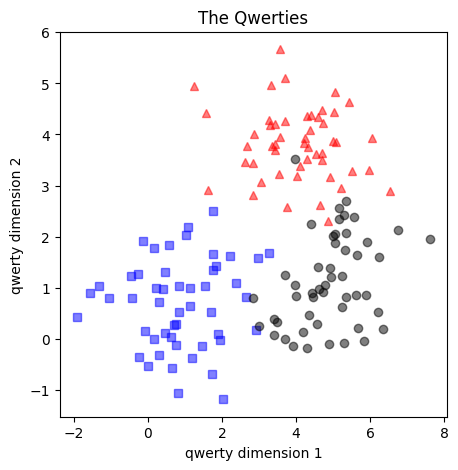

In [3]:
theData = createSomeData(50)

data = theData['data']
labels = theData['labels']

fig = plt.figure(figsize=(5,5))
plt.plot(data[np.where(labels==0)[0],0],data[np.where(labels==0)[0],1],'bs',alpha=.5)
plt.plot(data[np.where(labels==1)[0],0],data[np.where(labels==1)[0],1],'ko',alpha=.5)
plt.plot(data[np.where(labels==2)[0],0],data[np.where(labels==2)[0],1],'^r',alpha=.5)
plt.title('The Qwerties')
plt.xlabel('qwerty dimension 1')
plt.ylabel('qwerty dimension 2')
plt.show()

In [4]:
def createTheQwertyNet(nUnits, nLayers):

    class qwertyNet(nn.Module):
        def __init__(self, nUnits, nLayers):
            super().__init__()

            self.layers = nn.ModuleDict()
            self.nLayers = nLayers

            self.layers['input'] = nn.Linear(2, nUnits)

            for i in range(nLayers):
                self.layers[f'hidden{i}'] = nn.Linear(nUnits, nUnits)

            self.layers['output'] = nn.Linear(nUnits,3)

        def forward(self,x):
            x = self.layers['input'](x)

            for i in range(self.nLayers):
                x = F.relu( self.layers[f'hidden{i}'](x) )

            x = self.layers['output'](x)
            return x
    
    net = qwertyNet(nUnits, nLayers)

    lossfun = nn.CrossEntropyLoss()

    optimizer = torch.optim.SGD(net.parameters(), lr=.01)

    return net, lossfun, optimizer

In [5]:
def function2trainTheModel(nUnits, nLayers):

    numepochs = 50

    net, lossfun, optimizer = createTheQwertyNet(nUnits, nLayers)

    losses = torch.zeros(numepochs)
    trainAcc = []
    testAcc = []

    for epochi in range(numepochs):

        batchAcc = []
        batchLoss = []
        for X, y in train_data:

            yHat = net(X)
            loss = lossfun(yHat, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            batchLoss.append(loss.item())

            matches = torch.argmax(yHat, axis=1) == y
            matchesNumeric = matches.float()
            accuracyPct = 100*torch.mean(matchesNumeric)
            batchAcc.append( accuracyPct )

        trainAcc.append( np.mean(batchAcc) )

        losses[epochi] = np.mean(batchLoss)

        X,y = next(iter(test_data))
        with torch.no_grad():
            yHat = net(X)

        testAcc.append( 100*torch.mean((torch.argmax(yHat, axis=1)==y).float()) )

    return trainAcc, testAcc, losses, net

In [7]:
theData = createSomeData(200)
train_data = theData['train_data']
test_data = theData['test_data']

trainAcc, testAcc, losses, net = function2trainTheModel(80,1)

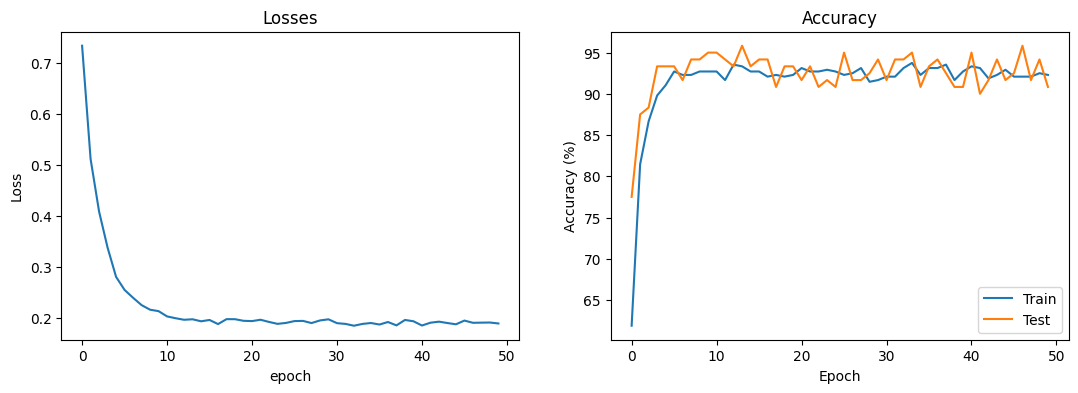

In [8]:
fig, ax = plt.subplots(1,2,figsize=(13,4))

ax[0].plot(losses.detach())
ax[0].set_ylabel('Loss')
ax[0].set_xlabel('epoch')
ax[0].set_title('Losses')

ax[1].plot(trainAcc, label='Train')
ax[1].plot(testAcc, label='Test')
ax[1].set_ylabel('Accuracy (%)')
ax[1].set_xlabel('Epoch')
ax[1].set_title('Accuracy')
ax[1].legend()
plt.show()

In [9]:
nNodesInModel = 80
layersRange = [1,5,10,20]
nDatapoints = np.arange(50, 551, 50)

legend = []

for lidx, layers in enumerate(layersRange):

    unitsperlayer = int(nNodesInModel/layersRange[lidx])
    net = createTheQwertyNet(unitsperlayer, layers)[0]

    nparams = np.sum([p.numel() for p in net.parameters() if p.requires_grad ])
    legend.append( '%s layers, %s units, %s params' %(layers, unitsperlayer, nparams) )
    print('This model will have %s layers, each with %s units, totalling %s parameters' %(layers, unitsperlayer, nparams))

This model will have 1 layers, each with 80 units, totalling 6963 parameters
This model will have 5 layers, each with 16 units, totalling 1459 parameters
This model will have 10 layers, each with 8 units, totalling 771 parameters
This model will have 20 layers, each with 4 units, totalling 427 parameters


In [11]:
results = np.zeros((len(nDatapoints),len(layersRange),2))

for didx, pnts in enumerate(nDatapoints):
    theData = createSomeData(pnts)
    train_data = theData['train_data']
    test_data = theData['test_data']


    for lidx, layers in enumerate(layersRange):

        unitsperlayer = int(nNodesInModel/layersRange[lidx])
        trainAcc, testAcc, losses, net = function2trainTheModel(unitsperlayer, layers)

        results[didx, lidx, 0] = np.mean( testAcc[-5:] )
        results[didx, lidx, 1] = torch.mean(losses[-5:] )

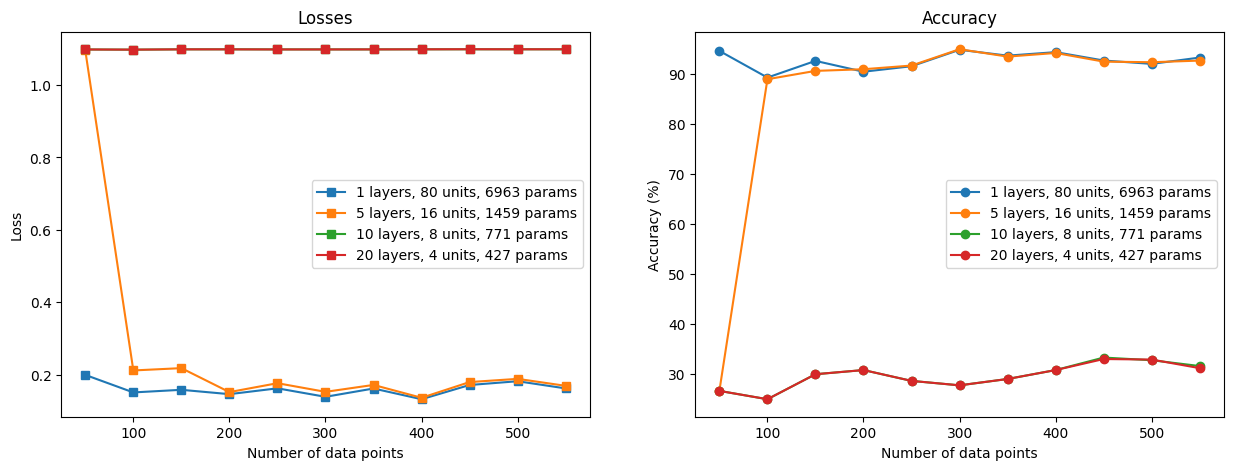

In [16]:
fig, ax = plt.subplots(1,2,figsize=(15,5))
ax[0].plot(nDatapoints,results[:,:,1],'s-')
ax[0].set_ylabel('Loss')
ax[0].set_xlabel('Number of data points')
ax[0].legend(legend)
ax[0].set_title('Losses')

ax[1].plot(nDatapoints, results[:,:,0], 'o-')
ax[1].set_ylabel('Accuracy (%)')
ax[1].set_xlabel('Number of data points')
ax[1].set_title('Accuracy')
ax[1].legend(legend)
plt.show()